# Module 3 Homework - Seaborn
Using a dataset about Pokemon combat statistic, we will practice data visualization using the seaborn library.  
<img src="https://cdn.arstechnica.net/wp-content/uploads/2020/07/pokemon-go-masks-800x450.jpg">

In this notebook, we will plot the relationships between different observations of the combat statistics of Pokémon. You will need to import a few packages, including `pandas`, `matplotlib.pyplot`, and `seaborn`. The data is stored in a csv file: https://raw.githubusercontent.com/csbfx/advpy122-data/master/Pokemon.csv

Here are the descriptions of this dataset:
- `#` - Pokedex entry number of the Pokemon
- `Name` - name of the Pokemon
- `Type 1` - each Pokemon has a type, this determines weakness/resistance to attacks [referred to as the primary type]
- `Type 2` - some Pokemon are dual type and have 2 [referred to as the secondary type]
- `Total` - sum of all stats that come after this, a general guide to how strong a Pokemon is
- `HP` - hit points, or health, defines how much damage a Pokemon can withstand before fainting
- `Attack` - the base modifier for normal attacks
- `Defense` - the base damage resistance against normal attacks
- `Sp. Atk` - special attack, the base modifier for special attacks
- `Sp. Def` - the base damage resistance against special attacks
- `Speed` - determines which Pokemon attacks first each round
- `Generation` - refers to which grouping/game series the Pokemon was released in
- `Legendary` - a boolean that identifies whether the Pokemon is legendary

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
%matplotlib inline

fp = "https://raw.githubusercontent.com/csbfx/advpy122-data/master/Pokemon.csv"
df = pd.read_csv(fp)

## Q1: Plot the relationship between Attack and Defense
Create a relationship plot using seaborn's `relplot` function. Plot `Attack` on the x-axis and `Defense` on the y-axis. Use `hue` to display the `HP` (hit point) for each datapoint. You can choose your favorite palette. Include a meaninful title in the plot. After creating the plot, insert a markdown cell :immediately following the plot to describe the relationship between Attack and Defense in this dataset.

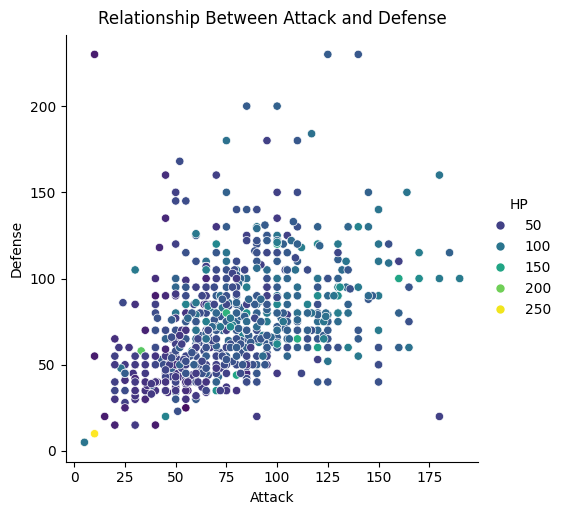

In [2]:
g = sns.relplot(
    data=df,
    x="Attack",
    y="Defense",
    hue="HP",
    palette="viridis",
)

g.fig.suptitle("Relationship Between Attack and Defense", y=1.02)

plt.show()

### From the plot, I observed....
There is a positive correlation between `Attack` and `Defense` and pokemon with higher attack stats tend to also have higher defense stat. There is a large cluster in the middle around 40-80 attack/defense and there doesn't seem to be a correlation with HP to attack and defense.

## Q2: Plot the relationship between Attack and Total using a hexbin plot
Create a hexbin plot using seaborn's `joinplot` function. Plot `Attack` on the x-axis and `Total` on the y-axis. You can choose the gridsize. Include a title for the plot "Attack vs total for all Pokemon". After generating the plot, insert a markdown cell to answer this question: The hexbin plot displays the relationship between `Attack` and `Total`, what else does this plot show?

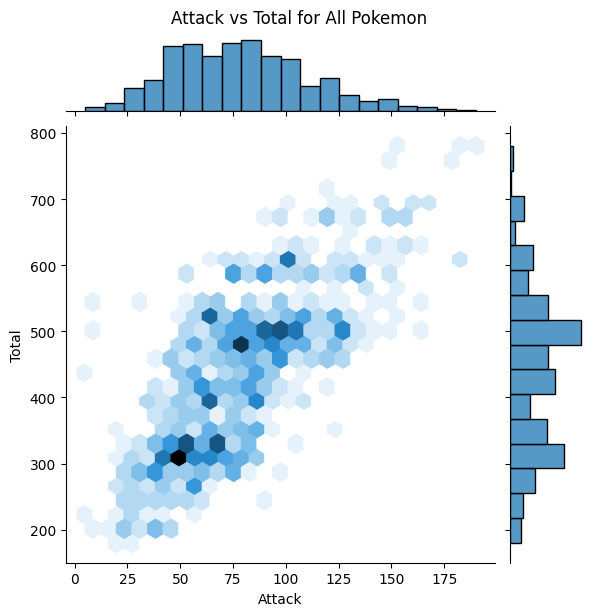

In [3]:
g = sns.jointplot(
    data=df,
    x="Attack",
    y="Total",
    kind="hex",
    gridsize=25
)

g.fig.suptitle("Attack vs Total for All Pokemon", y=1.02)

plt.show()

### From the plot, I observed....
There is a positive relationship between `Attack` and `Total` which makes sense since the attack stat also contributes to total. This plot also shows high density of pokemon using darker hue color of hexagon. I can see that most Pokemon are either around 300 total stat with 50 attack or 500 total stat with 100 attack.

## Q3: Create two categorical plots for Pokemon types. `Type 1` and `Type 2` .
For each plot, the unique values of `Type 1` or `Type 2` should be plotted along the y-axis, and the counts of Pokemon should be on the x-axis. Use the color red for the `Type 1` plot and blue for the `Type 2` plot. After the two plots are displayed, insert a markdown cell to write your findings: Which are the most common `Type 1` and `Type 2` Pokemons, and which are the most rare ones?

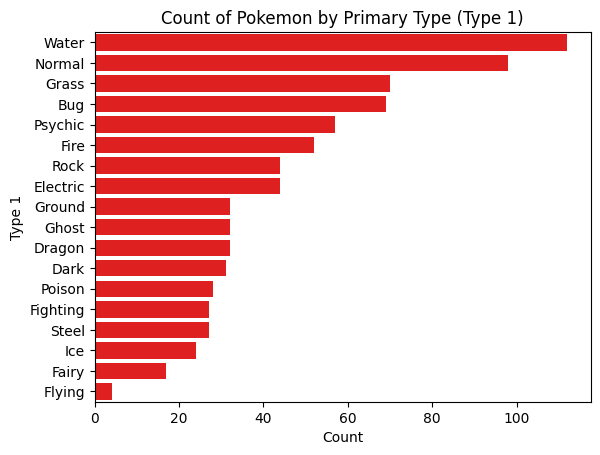

In [4]:
sns.countplot(
    data=df,
    y="Type 1",
    color="red",
    order=df["Type 1"].value_counts().index
)

plt.title("Count of Pokemon by Primary Type (Type 1)")
plt.xlabel("Count")
plt.ylabel("Type 1")

plt.show()

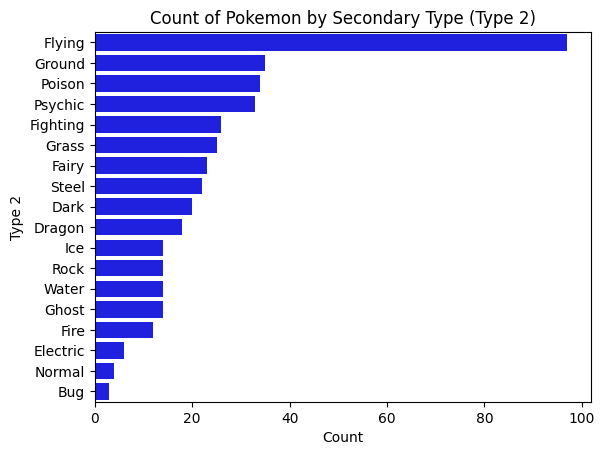

In [5]:
sns.countplot(
    data=df,
    y="Type 2",
    color="blue",
    order=df["Type 2"].value_counts().index
)

plt.title("Count of Pokemon by Secondary Type (Type 2)")
plt.xlabel("Count")
plt.ylabel("Type 2")

plt.show()

### From the plot, I observed....
The most common Type 1 pokemon is `water` type at around 110 followed closely by normal types. On the other hand, the most common Type 2 is `flying` type by a landslide at around 95. This beats out any other type 2 by over 50 count of pokemon.

The rarest Type 1 is flying type while Type 2's rarest is Bug type.

## Q4-6: Your own question
Come up with three more questions to further explore the pokemon dataset.

## Q4: Which Type 1 Pokémon Has the Highest Average Speed?

/tmp/ipython-input-475/2857602287.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


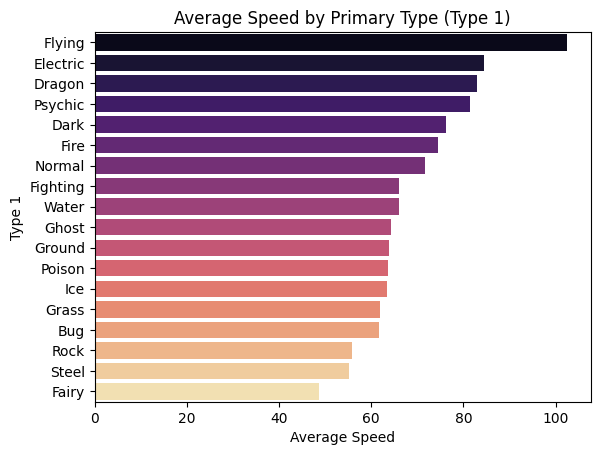

In [9]:
avg_speed = df.groupby("Type 1")["Speed"].mean().sort_values(ascending=False)

sns.barplot(
    x=avg_speed.values,
    y=avg_speed.index,
    palette="magma"
)

plt.title("Average Speed by Primary Type (Type 1)")
plt.xlabel("Average Speed")
plt.ylabel("Type 1")

plt.show()

# Q5: How Does Attack Vary Across Generations?
This graph shows that all generations from 1 through 6 has a balanced and consistent spread of attack stats with the median always being around 75.

/tmp/ipython-input-475/235173695.py:1: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(


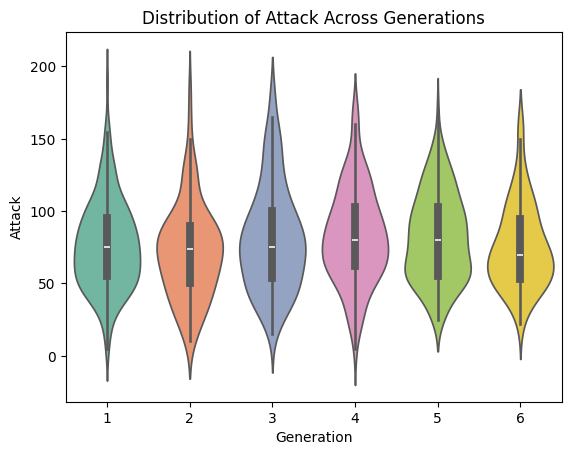

In [11]:
sns.violinplot(
    data=df,
    x="Generation",
    y="Attack",
    palette="Set2"
)

plt.title("Distribution of Attack Across Generations")
plt.xlabel("Generation")
plt.ylabel("Attack")

plt.show()

# Q6: How Many Legendaries Are There Among the Generations?
Based on the graph, we see that legendary pokemon are very rare and that there is an increase of legendaries being released every generation after gen 3.

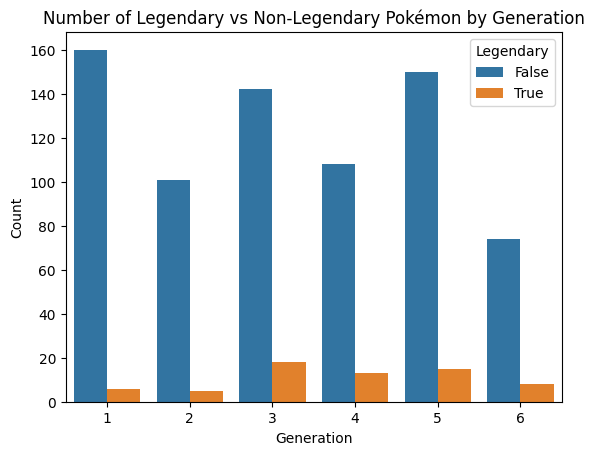

In [12]:
sns.countplot(
    data=df,
    x="Generation",
    hue="Legendary"
)

plt.title("Number of Legendary vs Non-Legendary Pokémon by Generation")
plt.xlabel("Generation")
plt.ylabel("Count")

plt.show()